In [50]:
# Import các thư viện pytorch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import PIL as pil

In [51]:
#đọc flie csv
data = pd.read_csv(
    '/home/vophilong/Documents/BTap_DeepLearning/BaiTapDeepLearning/VoPhiLong_2280601798/dataset/archive/car_purchasing.csv',
    encoding='latin1'
)

print(data.head())
#hiển thị 5 dòng đầu tiên của dữ liệu
print(data.head())

     customer name                                    customer e-mail  \
0    Martina Avila  cubilia.Curae.Phasellus@quisaccumsanconvallis.edu   
1    Harlan Barnes                                eu.dolor@diam.co.uk   
2  Naomi Rodriquez  vulputate.mauris.sagittis@ametconsectetueradip...   
3  Jade Cunningham                            malesuada@dignissim.com   
4     Cedric Leach     felis.ullamcorper.viverra@egetmollislectus.net   

        country  gender        age  annual Salary  credit card debt  \
0      Bulgaria       0  41.851720    62812.09301      11609.380910   
1        Belize       0  40.870623    66646.89292       9572.957136   
2       Algeria       1  43.152897    53798.55112      11160.355060   
3  Cook Islands       1  58.271369    79370.03798      14426.164850   
4        Brazil       1  57.313749    59729.15130       5358.712177   

     net worth  car purchase amount  
0  238961.2505          35321.45877  
1  530973.9078          45115.52566  
2  638467.1773      

In [52]:
#kiểm tra thông tin dữ liệu
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer name        500 non-null    object 
 1   customer e-mail      500 non-null    object 
 2   country              500 non-null    object 
 3   gender               500 non-null    int64  
 4   age                  500 non-null    float64
 5   annual Salary        500 non-null    float64
 6   credit card debt     500 non-null    float64
 7   net worth            500 non-null    float64
 8   car purchase amount  500 non-null    float64
dtypes: float64(5), int64(1), object(3)
memory usage: 35.3+ KB
None
           gender         age  annual Salary  credit card debt  \
count  500.000000  500.000000     500.000000        500.000000   
mean     0.506000   46.241674   62127.239608       9607.645049   
std      0.500465    7.978862   11703.378228       3489.187973   
min      0.000

In [53]:
# Tạo mô hình hồi quy tuyến tính bằng pytorch
class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)
    
    def forward(self, x):
        return self.linear(x)

In [54]:
#chọn các cột x và y
data.columns = data.columns.str.strip().str.lower()
X = data[['age', 'annual salary', 'credit card debt', 'net worth']].values
y = data['car purchase amount'].values

X_mean = X.mean(axis=0)
X_std  = X.std(axis=0)

y_mean = y.mean()
y_std  = y.std()

X = (X - X_mean) / X_std
y = (y - y_mean) / y_std


In [55]:
#Chia dữ liệu thành train và test
from sklearn.model_selection import train_test_split

# Chia dữ liệu: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Chuyển hóa thành tensor
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [56]:
# Tạo mô hình, hàm mất mát và bộ tối ưu hóa
model = LinearRegressionModel(input_dim=4, output_dim=1)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [57]:
# Huấn luyện mô hình
num_epochs = 1000
losses = []
for epoch in range(num_epochs):
    #Forward pass
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    losses.append(loss.item())
    #Backward pass và tối ưu hóa
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    #In thông tin mỗi 100 epoch
    if (epoch+1) % 100 == 0:

        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')    

Epoch [100/1000], Loss: 0.0156
Epoch [200/1000], Loss: 0.0003
Epoch [300/1000], Loss: 0.0000
Epoch [400/1000], Loss: 0.0000
Epoch [500/1000], Loss: 0.0000
Epoch [600/1000], Loss: 0.0000
Epoch [700/1000], Loss: 0.0000
Epoch [800/1000], Loss: 0.0000
Epoch [900/1000], Loss: 0.0000
Epoch [1000/1000], Loss: 0.0000


In [58]:
#Đánh giá mô hình
model.eval()
with torch.no_grad():
    #Tắt gradient computition 
    y_pred = model(X_test)
    test_loss = criterion(y_pred, y_test)
    
    #Tính R 2 độ chính xác
    ss_total = torch.sum((y_test - torch.mean(y_test))**2)
    ss_residual = torch.sum((y_test - y_pred)**2)
    r2_score = 1 - ss_residual / ss_total
    # In tất cả các giá trị đánh giá
    print(f'Test Loss (MSE): {test_loss.item():.4f}')
    print(f'R^2 Score: {r2_score.item():.4f}')
    print(f'Learning W: {model.linear.weight.data}')
    print(f'Learning b: {model.linear.bias.data}')

Test Loss (MSE): 0.0000
R^2 Score: 1.0000
Learning W: tensor([[ 6.2328e-01,  6.1089e-01, -7.6400e-06,  4.6687e-01]])
Learning b: tensor([1.7335e-06])


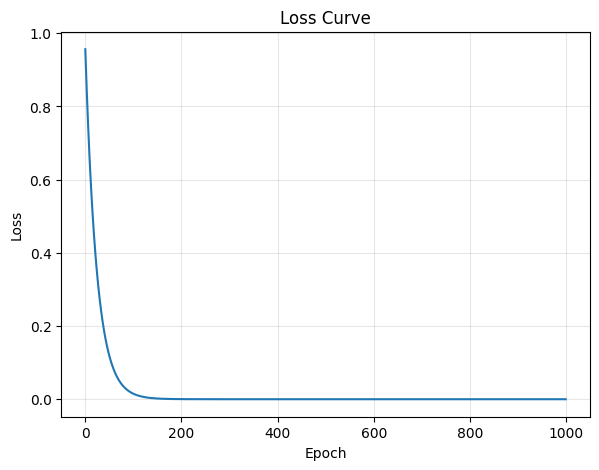

In [59]:
#Trực quan hóa kết quả dự đoán
plt.figure(figsize=(15,5))

# Subplot 1: Loss curve
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')  
plt.title('Loss Curve')
plt.grid(True, alpha = 0.3)



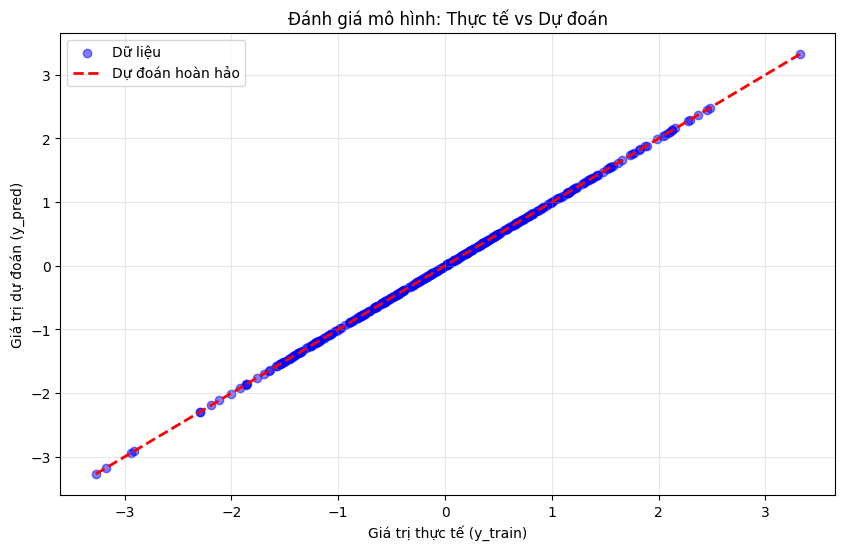

In [ ]:
# Mô hình sang chế độ đánh giá
model.eval()

# Dự đoán trên tập train để vẽ biểu đồ
with torch.no_grad():
    y_pred_train = model(X_train)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.scatter(y_train.numpy(), y_pred_train.numpy(), alpha=0.5, color='blue', label='Dữ liệu')

# Vẽ đường chéo lý tưởng (nếu dự đoán đúng 100% các điểm sẽ nằm trên đường này)
min_val = min(y_train.min(), y_pred_train.min())
max_val = max(y_train.max(), y_pred_train.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Dự đoán hoàn hảo')

plt.xlabel('Giá trị thực tế (y_train)')
plt.ylabel('Giá trị dự đoán (y_pred)')
plt.title('Đánh giá mô hình: Thực tế vs Dự đoán')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()